sigma = 2.0: starting simulation...
  sigma = 2.0: blow‑up time T = 2.9200, first vertex x = 26
sigma = 2.5: starting simulation...
  sigma = 2.5: blow‑up time T = 2.1800, first vertex x = 26


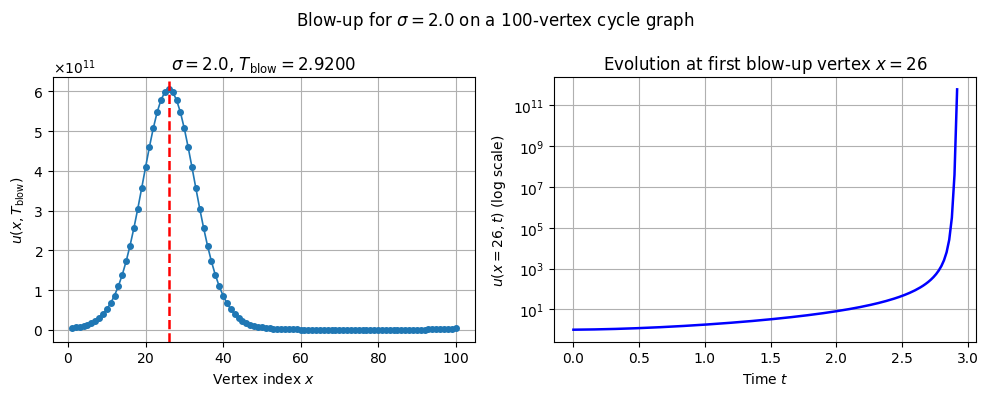

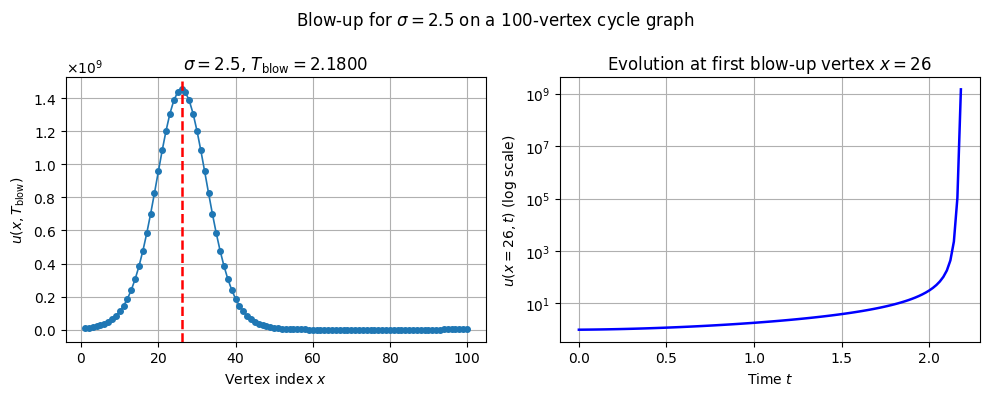

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags

# -------------------------------------------------------------------
# Parameters
# -------------------------------------------------------------------
N = 100                     # number of vertices
tau = 0.02                  # time step size
T_max = int(1e6)            # maximum number of iterations (safety)
threshold = 1e8             # blow‑up threshold
sigmas = [2.0, 2.5]         # nonlinear exponents (sigma=1.5 removed)

# Storage for results
u_finals = []       # spatial solution at blow‑up instant
T_blow = []         # blow‑up time
idx_blow = []       # index (0‑based) of the first vertex to blow up
hist_points = []    # time history at that vertex
time_axis = []      # corresponding time vector

# -------------------------------------------------------------------
# Construct the graph Laplacian matrix A (cycle graph, periodic tridiagonal)
# -------------------------------------------------------------------
# Main diagonal -2, sub/super diagonals 1, corners (0,N-1) and (N-1,0) set to 1
diagonals = [-2 * np.ones(N), np.ones(N-1), np.ones(N-1), 1, 1]
offsets = [0, 1, -1, -(N-1), (N-1)]
A = diags(diagonals, offsets, format='csr')
# Verify: A * ones(N) = 0

# -------------------------------------------------------------------
# Initial conditions
# -------------------------------------------------------------------
u0 = np.ones(N)
x = np.arange(N)
u1 = 0.1 + 0.01 * np.sin(2 * np.pi * x / N)   # non‑negative, spatial perturbation

# -------------------------------------------------------------------
# Main simulation loop over each sigma
# -------------------------------------------------------------------
for sigma in sigmas:
    print(f'sigma = {sigma:.1f}: starting simulation...')

    # Leap‑frog requires u at t = -tau and t = 0
    u_prev = u0 - tau * u1   # virtual previous step
    u_curr = u0.copy()
    t = 0.0

    # Store history (all time steps)
    U_history = [u0.copy()]   # first entry at t=0
    time_history = [0.0]

    for n in range(T_max):
        # Nonlinear term
        f = np.abs(u_curr) ** sigma
        # Laplacian (sparse matrix‑vector product)
        Lu = A.dot(u_curr).toarray().flatten() if hasattr(A.dot(u_curr), 'toarray') else A.dot(u_curr)
        # Time update (explicit leap‑frog)
        u_next = 2 * u_curr - u_prev + tau**2 * (Lu + f)
        t += tau

        # Check for blow‑up
        if np.max(np.abs(u_next)) > threshold or np.any(np.isnan(u_next)):
            U_history.append(u_next.copy())
            time_history.append(t)
            break

        # No blow‑up yet: update and store
        u_prev = u_curr
        u_curr = u_next
        U_history.append(u_curr.copy())
        time_history.append(t)

    # Convert history to numpy arrays for easier extraction
    U_history = np.array(U_history)          # shape: (num_steps, N)
    time_history = np.array(time_history)

    # Store final results
    u_final = U_history[-1, :]               # solution at blow‑up
    T = time_history[-1]
    u_finals.append(u_final)
    T_blow.append(T)

    # Find vertex with maximum absolute value at blow‑up (first to blow)
    idx_max = np.argmax(np.abs(u_final))
    idx_blow.append(idx_max)                 # 0‑based
    # Extract history at that vertex
    hist_u = U_history[:, idx_max]
    hist_points.append(hist_u)
    time_axis.append(time_history)

    print(f'  sigma = {sigma:.1f}: blow‑up time T = {T:.4f}, first vertex x = {idx_max+1}')

# -------------------------------------------------------------------
# Plotting: one figure per sigma
# -------------------------------------------------------------------
for i, sigma in enumerate(sigmas):
    u_final = u_finals[i]
    T = T_blow[i]
    x_blow = idx_blow[i] + 1   # convert to 1‑based for display
    hist_u = hist_points[i]
    time_t = time_axis[i]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # ----- Left subplot: spatial distribution at blow‑up -----
    ax1.plot(np.arange(1, N+1), u_final, 'o-', linewidth=1.2, markersize=4)
    ax1.axvline(x=x_blow, color='r', linestyle='--', linewidth=1.8)
    ax1.set_xlabel('Vertex index $x$')
    ax1.set_ylabel(r'$u(x, T_{\rm blow})$')
    ax1.set_title(f'$\\sigma = {sigma:.1f}$, $T_{{\\rm blow}} = {T:.4f}$')
    ax1.grid(True)
    # Force scientific notation to appear as 10^8 instead of 1e8
    ax1.ticklabel_format(useMathText=True)
    ax1.yaxis.get_major_formatter().set_useMathText(True)

    # ----- Right subplot: time evolution at the first blow‑up vertex (log y) -----
    ax2.plot(time_t, hist_u, 'b-', linewidth=1.8)
    ax2.set_xlabel('Time $t$')
    ax2.set_ylabel(r'$u(x=%d, t)$ (log scale)' % x_blow)
    ax2.set_title(f'Evolution at first blow‑up vertex $x = {x_blow}$')
    ax2.set_yscale('log')          # avoid steep 'right‑angle' appearance
    ax2.grid(True)

    fig.suptitle(f'Blow‑up for $\\sigma = {sigma:.1f}$ on a 100‑vertex cycle graph', fontsize=12)
    plt.tight_layout()

plt.show()